In [1]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rasterio.mask import mask
from rasterio.plot import show
from rasterio.plot import plotting_extent
from rasterio.warp import Resampling, calculate_default_transform, reproject


In [2]:
def clip_raster_to_shapes(raster_src, gdf):
    clips = {}
    for idx, geom in gdf.geometry.items():
        out_image, out_transform = mask(
            raster_src, [geom], crop=True, filled=False, all_touched=True
        )

        arr = out_image[0] # First band
        arr = np.ma.masked_equal(arr, raster_src.nodata)
        clips[idx] = (arr, out_transform)

    return gdf, clips

In [3]:
def plot_shapes(idx, gdf, clips, vmin=None, vmax=None):
    arr, transform = clips[idx]
    fig, ax = plt.subplots(figsize=((8, 8)))

    extent = plotting_extent(arr, transform)
    im = ax.imshow(
        arr, 
        extent=extent, 
        cmap='terrain',
        vmin=vmin,
        vmax=vmax,
    )

    gdf.loc[[idx]].boundary.plot(
        ax=ax, 
        color="black", 
        linewidth=1.5
    )

    ax.set_title(f"Shape {idx}")
    plt.colorbar(im, ax=ax, label="Elevation", shrink=0.8)
    plt.show()

In [4]:
def reproject_raster(src_path, dst_path, dst_crs, resolution=None,
                     resampling=Resampling.bilinear):
    """
    Reproject a raster to dst_crs and write it to dst_path.
 
    resolution : optional pixel size in the units of dst_crs (e.g. 30 for 30 m).
                 If None, rasterio picks a size close to the original.
    resampling : bilinear is a good default for continuous data like elevation.
                 Never use nearest for slope work if you can avoid it; it
                 produces blocky, noisy slopes.
    """
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds,
            resolution=resolution,
        )
 
        nodata = src.nodata if src.nodata is not None else -9999.0
 
        profile = src.profile.copy()
        profile.update(
            crs=dst_crs,
            transform=transform,
            width=width,
            height=height,
            dtype="float32",   # bilinear resampling produces fractional values
            nodata=nodata,
        )
 
        with rasterio.open(dst_path, "w", **profile) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band),
                    destination=rasterio.band(dst, band),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    dst_nodata=nodata,
                    resampling=resampling,
                )

In [5]:
def calculate_slopes(raster_src):
    dem = raster_src.read(1, masked=True).astype(float).filled(np.nan) # Pixels matching the nodata value are flagged as masked so as to not skew math functions
    dx, dy = raster_src.res # Get the real world dimensions of a single raster pixel
    profile = raster_src.profile

    gy, gx = np.gradient(dem, dy, dx)
    slope = np.degrees(np.arctan(np.hypot(gx, gy))).astype('float32')

    profile.update(dtype="float32", nodata=np.nan)
    with rasterio.open("slope.tif", "w", **profile) as dst:
        dst.write(slope, 1)

    return slope

In [6]:
def summarize_stats(clips):
    stats = {}
    for idx, (arr, transform) in clips.items():
        vals = arr.compressed() # Extracts and returns all non-masked data as a standard 1d array

        if vals.size == 0:
            continue

        stats[idx] = {
            "min": vals.min(),
            "max": vals.max(),
            "mean": vals.mean(),
            "median": np.median(vals),
            "num_pixels": vals.size
        }

    return stats

In [7]:
def categorize_geometries(gdf, clips):
    stats = pd.DataFrame(summarize_stats(clips)).T

    stats['category'] = pd.cut(
        x=stats['median'], # The 1d array or series to be cut
        bins=[0, 4, 8, 15, np.inf], # The list of bin edges
        labels=['flat', 'mild', 'medium', 'steep'],
        include_lowest=True
    )

    gdf['slope_catetory'] = stats['category']

In [8]:
raster_src = rasterio.open("elevation_raster_data.tif")
gdf = gpd.read_file("../exports/ghe_locations.geojson")

if gdf.crs != raster_src.crs:
    gdf = gdf.to_crs(raster_src.crs)

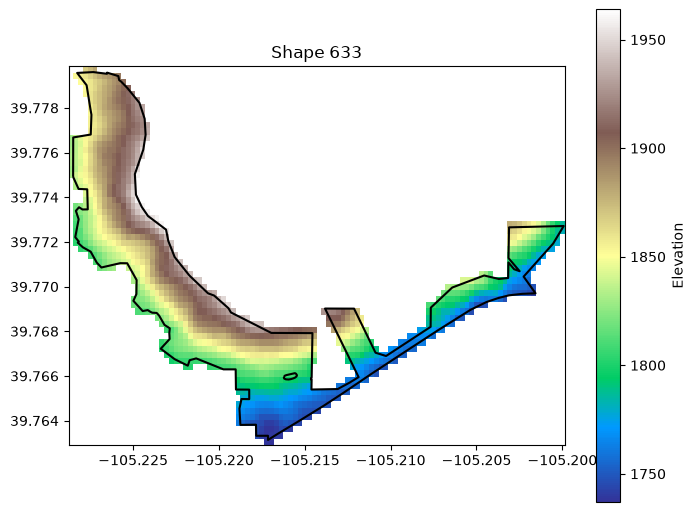

In [9]:
gdf, clips = clip_raster_to_shapes(raster_src, gdf)
plot_shapes(633, gdf, clips)

In [10]:
reproject_raster(
    src_path='elevation_raster_data.tif',
    dst_path='reprojected_elevation_raster_data.tif',
    dst_crs=gdf.estimate_utm_crs()
)

In [11]:
reproject_raster = rasterio.open('reprojected_elevation_raster_data.tif')

In [12]:
slope = calculate_slopes(reproject_raster)
print(type(slope))

<class 'numpy.ndarray'>


In [13]:
slope_raster_src = rasterio.open('slope.tif')
gdf, slope_clips = clip_raster_to_shapes(slope_raster_src, gdf.to_crs(gdf.estimate_utm_crs()))

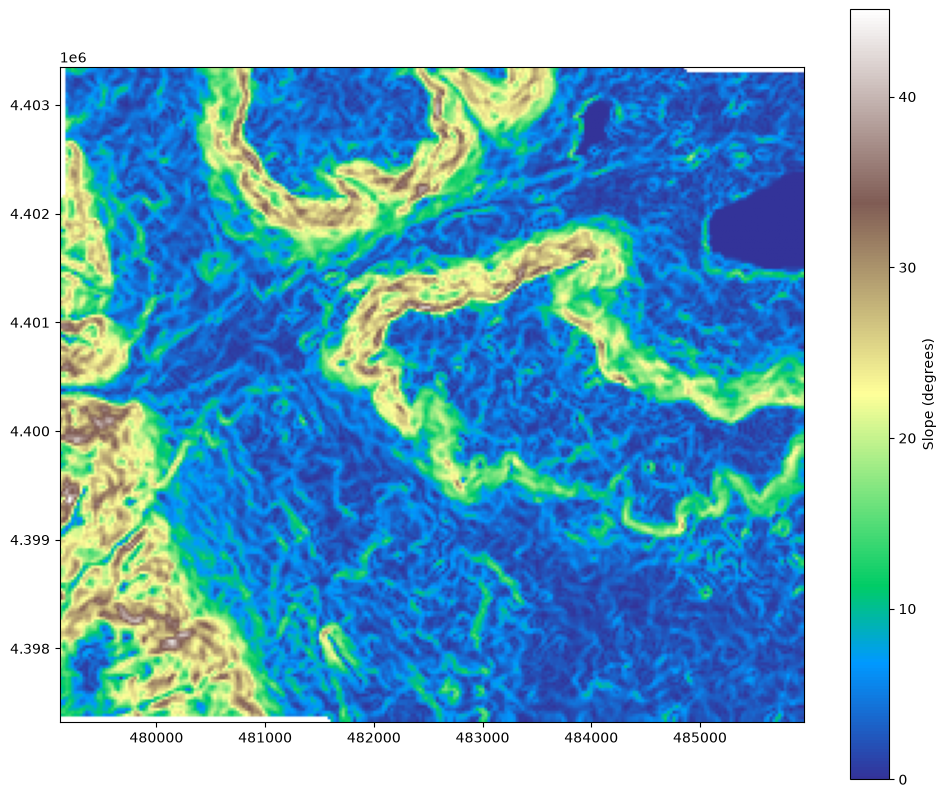

In [14]:
extent = plotting_extent(slope_raster_src.read(1), slope_raster_src.transform)
fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(
    slope_raster_src.read(1),
    extent=extent,
    cmap="terrain",
    origin="upper"
)

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Slope (degrees)")

plt.show()

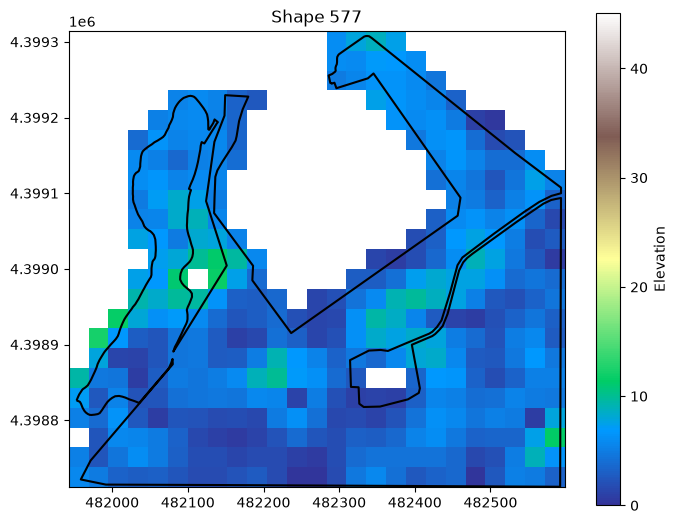

In [15]:
vmin, vmax = np.nanmin(slope), np.nanmax(slope)
plot_shapes(577, gdf, slope_clips, vmin, vmax)

In [16]:
categorize_geometries(gdf, slope_clips)
gdf.head()

,name,landuse,leisure,natural,boundary,amenity,type,district_system_type,geometry,slope_catetory
0,,,,,,parking,District System,Central Hot Water,"POLYGON ((480655.13 4400056.981, 480661.744 44...",mild
1,,,,,,parking,District System,Central Hot Water,"POLYGON ((485138.033 4400540.469, 485138.674 4...",mild
2,,,,,,parking,District System,Central Hot Water,"POLYGON ((481925.053 4398474.743, 481927.537 4...",flat
3,,,,,,parking,District System,Central Hot Water,"POLYGON ((480405.104 4400544.779, 480404.292 4...",mild
4,,,,,,parking,District System,Central Hot Water,"POLYGON ((480217.794 4400693.049, 480220.486 4...",flat


In [17]:
# raster_src.close()